
# Tradeoff analysis: expected_samples vs NDCG@10 (large vs xl)

Sweep `expected_samples` for the Weird oracle across Mohajer, Quick Sort (Classic), and PRP Sort (Classic) on BEIR benchmarks. Results are split by rerank matrix model (e.g., flan-t5-large vs flan-t5-xl), and we plot both NDCG@10 and comparison counts.


In [2]:

from typing import Sequence

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ireranker.data.loaders import load_beir_dataset
from ireranker.evaluation.beir import evaluate_rankers_beir
from ireranker.rankers import get_ranker
from ireranker.oracles import WeirdSamplingMatrixOracle

plt.style.use("ggplot")


2025-12-04 16:07:45.480 | INFO     | ireranker.config:<module>:14 - PROJ_ROOT path is: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker


In [3]:

from pathlib import Path
import json

CONFIG_PATH = Path("../config/beir_eval.json").resolve()
cfg = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}
ALL_DATASETS = [d.lower() for d in cfg.get("datasets", [])]
LIGHT_EXCLUDE = {d.lower() for d in cfg.get("light_exclude", [])}
LIGHT_DATASETS = [d for d in ALL_DATASETS if d not in LIGHT_EXCLUDE]

SEEDS = [42]
K_VALUES = [10]
EXPECTED_SAMPLES = np.linspace(0.0, 2.0, 20)
RANKERS = ["mohajer (ir)", "quick sort (classic)", "prp sort (classic)"]
MATRIX_MODELS = ["flan-t5-large", "flan-t5-xl"]

print("Datasets (light mode):", ", ".join(LIGHT_DATASETS))
print(f"Running {len(SEEDS)} seeds: {SEEDS}")
print(f"Evaluating expected_samples values: {EXPECTED_SAMPLES[0]:.2f}..{EXPECTED_SAMPLES[-1]:.2f} ({len(EXPECTED_SAMPLES)} points)")
print("Rankers:", ", ".join(RANKERS))
print("Matrix models:", ", ".join(MATRIX_MODELS))


Datasets (light mode): webis-touche2020, trec-covid, scifact
Running 1 seeds: [42]
Evaluating expected_samples values: 0.00..2.00 (20 points)
Rankers: mohajer (ir), quick sort (classic), prp sort (classic)
Matrix models: flan-t5-large, flan-t5-xl


In [4]:
def evaluate_expected_samples(
    dataset_name: str,
    expected_values: Sequence[float],
    seeds: Sequence[int],
    ranker_names: Sequence[str],
    matrix_models: Sequence[str],
) -> pd.DataFrame:
    rows = []
    for matrix_model in matrix_models:
        dataset = load_beir_dataset(dataset_name, split="test", matrix_model=matrix_model)
        task_qids = [t.query_id for t in dataset.tasks]
        for seed in seeds:
            for expected in expected_values:
                for ranker_name in ranker_names:
                    oracle = WeirdSamplingMatrixOracle(seed=seed, expected_samples=expected)
                    ranker = get_ranker(ranker_name, oracle=oracle, seed=seed)
                    ranker.set_dataset(
                        dataset_name,
                        split="test",
                        query_ids=task_qids,
                        matrix_model=matrix_model,
                    )
                    result = evaluate_rankers_beir([ranker], dataset, K_VALUES, seed=seed)[0]
                    rows.append(
                        {
                            "dataset": dataset_name,
                            "matrix_model": matrix_model,
                            "ranker": ranker_name,
                            "seed": seed,
                            "expected_samples": expected,
                            "NDCG@10": float(result["NDCG"]),
                            "MAP@10": float(result["MAP"]),
                            "Recall@10": float(result["Recall"]),
                            "P@10": float(result["Precision"]),
                            "Comparisons": int(result["Comparisons"]),
                            "NDCG_per_comp": float(result["NDCG_per_comp"]),
                        }
                    )
    return pd.DataFrame(rows).sort_values(
        ["dataset", "matrix_model", "ranker", "seed", "expected_samples"]
    ).reset_index(drop=True)


def evaluate_bm25_baseline(
    dataset_name: str,
    seeds: Sequence[int],
    matrix_models: Sequence[str],
) -> pd.DataFrame:
    rows = []
    for matrix_model in matrix_models:
        dataset = load_beir_dataset(dataset_name, split="test", matrix_model=matrix_model)
        task_qids = [t.query_id for t in dataset.tasks]
        for seed in seeds:
            ranker = get_ranker("bm25", seed=seed)
            ranker.set_dataset(
                dataset_name,
                split="test",
                query_ids=task_qids,
                matrix_model=matrix_model,
            )
            result = evaluate_rankers_beir([ranker], dataset, K_VALUES, seed=seed)[0]
            rows.append(
                {
                    "dataset": dataset_name,
                    "matrix_model": matrix_model,
                    "ranker": "bm25",
                    "seed": seed,
                    "expected_samples": float("nan"),
                    "NDCG@10": float(result["NDCG"]),
                    "MAP@10": float(result["MAP"]),
                    "Recall@10": float(result["Recall"]),
                    "P@10": float(result["Precision"]),
                    "Comparisons": int(result["Comparisons"]),
                    "NDCG_per_comp": float(result["NDCG_per_comp"]),
                }
            )
    return pd.DataFrame(rows).sort_values(["dataset", "matrix_model", "seed"]).reset_index(drop=True)


tradeoff_df = pd.concat(
    [evaluate_expected_samples(ds, EXPECTED_SAMPLES, SEEDS, RANKERS, MATRIX_MODELS) for ds in LIGHT_DATASETS],
    ignore_index=True,
) if LIGHT_DATASETS else pd.DataFrame()

bm25_df = pd.concat(
    [evaluate_bm25_baseline(ds, SEEDS, MATRIX_MODELS) for ds in LIGHT_DATASETS],
    ignore_index=True,
) if LIGHT_DATASETS else pd.DataFrame()

tradeoff_df.head(), bm25_df.head()

/home/jerefigo/.local/lib/python3.10/site-packages/beir/util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


2025-12-04 16:07:47.142 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/webis-touche2020
2025-12-04 16:07:49.507 | INFO     | ireranker.data.loaders:_load_rerank_matrix:170 - Loaded rerank matrix for webis-touche2020/test (queries: 49)
2025-12-04 16:07:49.508 | INFO     | ireranker.data.loaders:load_beir_dataset:262 - Using rerank matrix for 49 queries in webis-touche2020/test
2025-12-04 16:07:49.512 | INFO     | ireranker.data.loaders:load_beir_dataset:272 - Query coverage for webis-touche2020/test -> matrix: 49, qrels: 49, shared: 49, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  3.08it/s]


2025-12-04 16:08:08.193 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/webis-touche2020
2025-12-04 16:08:10.124 | INFO     | ireranker.data.loaders:_load_rerank_matrix:170 - Loaded rerank matrix for webis-touche2020/test (queries: 49)
2025-12-04 16:08:10.124 | INFO     | ireranker.data.loaders:load_beir_dataset:262 - Using rerank matrix for 49 queries in webis-touche2020/test
2025-12-04 16:08:10.125 | INFO     | ireranker.data.loaders:load_beir_dataset:272 - Query coverage for webis-touche2020/test -> matrix: 49, qrels: 49, shared: 49, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  2.41it/s]


...

2025-12-04 16:14:16.342 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/scifact
2025-12-04 16:14:18.272 | INFO     | ireranker.data.loaders:_load_rerank_matrix:170 - Loaded rerank matrix for scifact/test (queries: 300)
2025-12-04 16:14:18.273 | INFO     | ireranker.data.loaders:load_beir_dataset:262 - Using rerank matrix for 300 queries in scifact/test
2025-12-04 16:14:18.273 | INFO     | ireranker.data.loaders:load_beir_dataset:272 - Query coverage for scifact/test -> matrix: 300, qrels: 300, shared: 300, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  4.31it/s]


2025-12-04 16:14:18.619 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/scifact
2025-12-04 16:14:20.472 | INFO     | ireranker.data.loaders:_load_rerank_matrix:170 - Loaded rerank matrix for scifact/test (queries: 300)
2025-12-04 16:14:20.473 | INFO     | ireranker.data.loaders:load_beir_dataset:262 - Using rerank matrix for 300 queries in scifact/test
2025-12-04 16:14:20.474 | INFO     | ireranker.data.loaders:load_beir_dataset:272 - Query coverage for scifact/test -> matrix: 300, qrels: 300, shared: 300, matrix-only: 0, qrels-only: 0


Evaluating rankers: 100%|██████████| 1/1 [00:00<00:00,  4.56it/s]


(            dataset   matrix_model        ranker  seed  expected_samples  \
 0  webis-touche2020  flan-t5-large  mohajer (ir)    42          0.000000   
 1  webis-touche2020  flan-t5-large  mohajer (ir)    42          0.105263   
 2  webis-touche2020  flan-t5-large  mohajer (ir)    42          0.210526   
 3  webis-touche2020  flan-t5-large  mohajer (ir)    42          0.315789   
 4  webis-touche2020  flan-t5-large  mohajer (ir)    42          0.421053   
 
    NDCG@10   MAP@10  Recall@10     P@10  Comparisons  NDCG_per_comp  
 0  0.10158  0.02432    0.03871  0.07551        11368       0.000009  
 1  0.16200  0.03798    0.08829  0.14694        12232       0.000013  
 2  0.19582  0.05768    0.12437  0.19184        12250       0.000016  
 3  0.21343  0.05730    0.12213  0.20612        12156       0.000018  
 4  0.21874  0.06911    0.13509  0.21633        12079       0.000018  ,
             dataset   matrix_model ranker  seed  expected_samples  NDCG@10  \
 0  webis-touche2020  flan-t5-

In [5]:

best_overall = tradeoff_df.loc[tradeoff_df["NDCG@10"].idxmax()]
mean_by_ds_r_model = (
    tradeoff_df.groupby(["dataset", "matrix_model", "ranker", "expected_samples"])["NDCG@10"]
    .mean()
    .reset_index()
)
best_by_dataset_r_model = mean_by_ds_r_model.loc[
    mean_by_ds_r_model.groupby(["dataset", "matrix_model", "ranker"])["NDCG@10"].idxmax()
][["dataset", "matrix_model", "ranker", "expected_samples", "NDCG@10"]]

best_overall, best_by_dataset_r_model


(dataset                     trec-covid
 matrix_model                flan-t5-xl
 ranker              prp sort (classic)
 seed                                42
 expected_samples              1.789474
 NDCG@10                        0.78438
 MAP@10                         0.02001
 Recall@10                      0.02144
 P@10                              0.83
 Comparisons                      41269
 NDCG_per_comp                 0.000019
 Name: 217, dtype: object,
               dataset   matrix_model                ranker  expected_samples  \
 12            scifact  flan-t5-large          mohajer (ir)          1.263158   
 39            scifact  flan-t5-large    prp sort (classic)          2.000000   
 59            scifact  flan-t5-large  quick sort (classic)          2.000000   
 76            scifact     flan-t5-xl          mohajer (ir)          1.684211   
 99            scifact     flan-t5-xl    prp sort (classic)          2.000000   
 110           scifact     flan-t5-xl  quick so

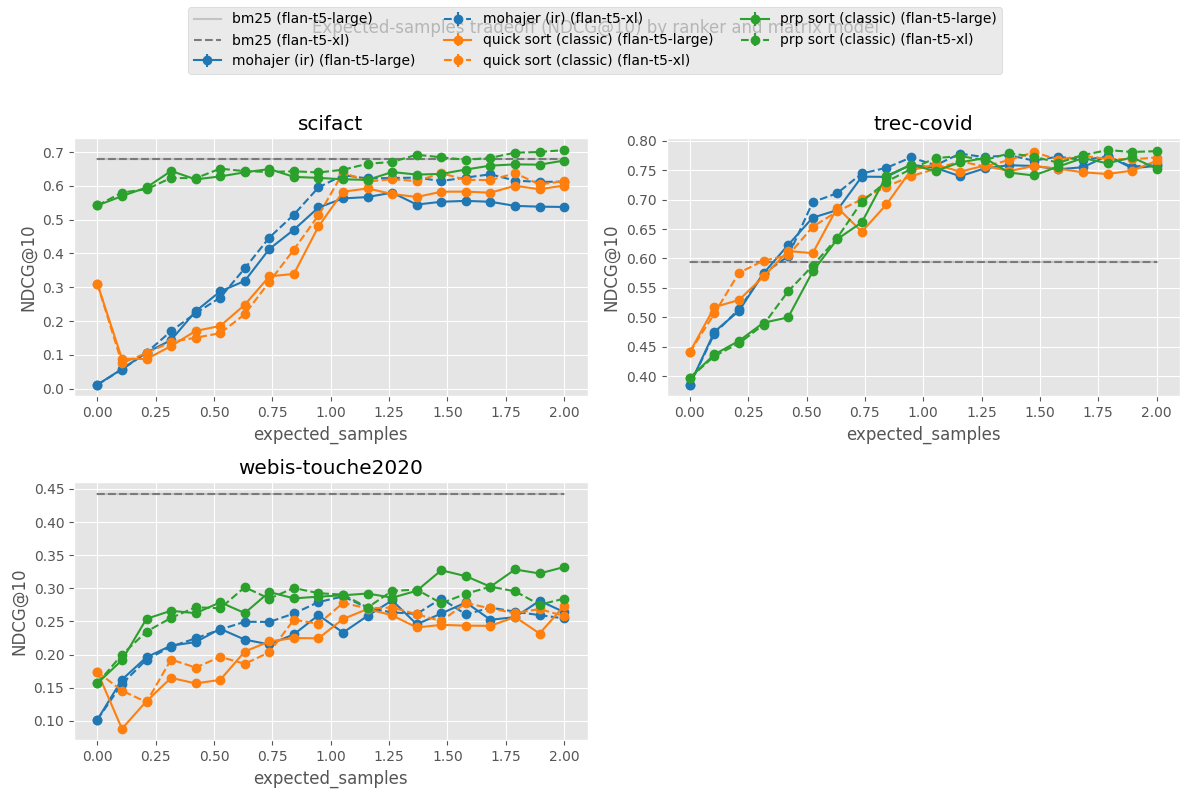

In [6]:
colors = plt.cm.tab10.colors
linestyles = {model: style for model, style in zip(MATRIX_MODELS, ["-", "--", ":", "-."])}
baseline_colors = {model: plt.cm.Greys(0.35 + 0.25 * idx) for idx, model in enumerate(MATRIX_MODELS)}
unique_ds = sorted(tradeoff_df["dataset"].unique())

bm25_ndcg = (
    bm25_df.groupby(["dataset", "matrix_model"])["NDCG@10"]
    .agg(["mean", "std"])
    .reset_index()
    if not bm25_df.empty
    else pd.DataFrame(columns=["dataset", "matrix_model", "mean", "std"])
)

fig, axes = plt.subplots(
    nrows=(len(unique_ds) + 1) // 2,
    ncols=2 if len(unique_ds) > 1 else 1,
    figsize=(12, 4 * ((len(unique_ds) + 1) // 2)),
    squeeze=False,
)

for idx, ds in enumerate(unique_ds):
    ax = axes[idx // 2][idx % 2]
    ds_data = tradeoff_df[tradeoff_df["dataset"] == ds]
    stats = (
        ds_data.groupby(["matrix_model", "ranker", "expected_samples"])["NDCG@10"]
        .agg(["mean", "std"])
        .reset_index()
    )
    for ridx, ranker_name in enumerate(RANKERS):
        for model in MATRIX_MODELS:
            sub = stats[(stats["ranker"] == ranker_name) & (stats["matrix_model"] == model)]
            if sub.empty:
                continue
            color = colors[ridx % len(colors)]
            ax.errorbar(
                sub["expected_samples"],
                sub["mean"],
                yerr=sub["std"],
                fmt="o",
                linestyle=linestyles.get(model, "-"),
                label=f"{ranker_name} ({model})",
                color=color,
            )

    x_min, x_max = ds_data["expected_samples"].min(), ds_data["expected_samples"].max()
    ds_baseline = bm25_ndcg[bm25_ndcg["dataset"] == ds]
    for _, row in ds_baseline.iterrows():
        x_range = np.array([x_min, x_max])
        color = baseline_colors.get(row["matrix_model"], "black")
        ax.plot(
            x_range,
            [row["mean"], row["mean"]],
            linestyle=linestyles.get(row["matrix_model"], "--"),
            color=color,
            label=f"bm25 ({row['matrix_model']})",
        )
        if row["std"] > 0:
            ax.fill_between(
                x_range,
                row["mean"] - row["std"],
                row["mean"] + row["std"],
                color=color,
                alpha=0.12,
                linewidth=0,
            )

    ax.set_title(ds)
    ax.set_xlabel("expected_samples")
    ax.set_ylabel("NDCG@10")
    ax.grid(True)

# Hide unused subplots
for j in range(len(unique_ds), axes.size):
    fig.delaxes(axes.flatten()[j])

handles, labels = axes[0][0].get_legend_handles_labels()
dedup = dict(zip(labels, handles))
fig.legend(dedup.values(), dedup.keys(), loc="upper center", ncol=min(len(dedup), 3))
fig.suptitle("Expected-samples tradeoff (NDCG@10) by ranker and matrix model")
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


- Datasets and light-mode filtering come from `config/beir_eval.json`.
- `MATRIX_MODELS` lists the rerank matrix variants; adjust if your local cache uses different names.
- Increase `SEEDS` for stability; expanding `EXPECTED_SAMPLES` or datasets will increase runtime.
